## SETUP


In [1]:
import json, glob, pandas as pd, matplotlib.pyplot as plt, numpy as np

def load_all_entries(pattern):
    entries = []
    for f in sorted(glob.glob(pattern)):
        data = json.load(open(f))
        entries.extend(data['entries'])
    return entries


### Load all multi-agent entries


In [2]:
entries = load_all_entries('multi/benchmark_279_batch_*.json')
print(f'Loaded {len(entries)} entries')

flagged = [e for e in entries if len(e.get('phase4_findings', [])) > 0]
resolved = [e for e in flagged if e['exit_status'] == 'SUCCESS']
unresolved = [e for e in flagged if e['exit_status'] == 'ABORT_STRATEGY']
print(f'Entries with phase4 findings: {len(flagged)}')
print(f'  -> Resolved (SUCCESS):  {len(resolved)}')
print(f'  -> Unresolved (ABORT):  {len(unresolved)}')


Loaded 279 entries
Entries with phase4 findings: 127
  -> Resolved (SUCCESS):  46
  -> Unresolved (ABORT):  81


# Overall Resolution Rate

Of all multi-agent entries where the validator (`phase4_findings`) flagged at least one issue, what fraction eventually exits as SUCCESS?


Overall Resolution Rate:
  Flagged entries:     127
  Resolved (SUCCESS):  46  (36.2%)
  Unresolved (ABORT):  81  (63.8%)

Interpretation: 36.2% of validator-flagged runs eventually succeed.
The remaining 63.8% are fatal.


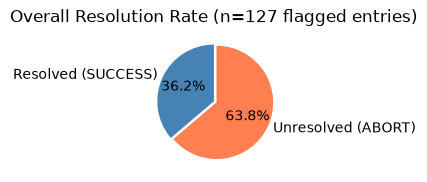

In [3]:
total_flagged = len(flagged)
total_resolved = len(resolved)
total_unresolved = len(unresolved)
pct = total_resolved / total_flagged * 100

print(f'Overall Resolution Rate:')
print(f'  Flagged entries:     {total_flagged}')
print(f'  Resolved (SUCCESS):  {total_resolved}  ({pct:.1f}%)')
print(f'  Unresolved (ABORT):  {total_unresolved}  ({100-pct:.1f}%)')
print()
print(f'Interpretation: {pct:.1f}% of validator-flagged runs eventually succeed.')
print(f'The remaining {100-pct:.1f}% are fatal.')

fig, ax = plt.subplots(figsize=(4, 4))
wedges, texts, autotexts = ax.pie(
    [total_resolved, total_unresolved],
    labels=['Resolved (SUCCESS)', 'Unresolved (ABORT)'],
    colors=['steelblue', 'coral'],
    autopct='%1.1f%%',
    startangle=90,
    explode=(0, 0.05)
)
for t in autotexts:
    t.set_fontsize(10)
ax.set_title(f'Overall Resolution Rate (n={total_flagged} flagged entries)')
plt.tight_layout()
plt.savefig('charts/iter/resolution_overall.png', dpi=100)
plt.show()


# Resolution Rate by Difficulty

Broken down by task difficulty: how does the validator's resolvability vary?


Easy  : 11/25 = 44.0% resolve
Medium: 24/76 = 31.6% resolve
Hard  : 11/26 = 42.3% resolve


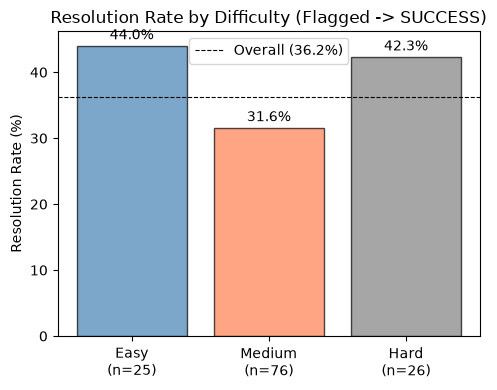

In [4]:
diffs = ['Easy', 'Medium', 'Hard']
diff_data = []
for diff in diffs:
    fl = [e for e in flagged if e['difficulty'] == diff]
    if len(fl) == 0:
        continue
    rs = len([e for e in fl if e['exit_status'] == 'SUCCESS'])
    pct = rs / len(fl) * 100
    print(f'{diff:6s}: {rs}/{len(fl)} = {pct:.1f}% resolve')
    diff_data.append({'difficulty': diff, 'flagged': len(fl), 'resolved': rs, 'pct': pct})

overall_pct = sum(d['resolved'] for d in diff_data) / sum(d['flagged'] for d in diff_data) * 100
fig, ax = plt.subplots(figsize=(5, 4))
x = np.arange(len(diff_data))
bars = ax.bar(x, [d['pct'] for d in diff_data], color=['steelblue','coral','gray'], edgecolor='black', alpha=0.7)
ax.set_title('Resolution Rate by Difficulty (Flagged -> SUCCESS)')
ax.set_ylabel('Resolution Rate (%)')
ax.set_xticks(x)
ax.set_xticklabels([f"{d['difficulty']}\n(n={d['flagged']})" for d in diff_data])
ax.axhline(overall_pct, color='black', linewidth=0.8, linestyle='--', label=f'Overall ({overall_pct:.1f}%)')
ax.legend()
for bar, d in zip(bars, diff_data):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{d["pct"]:.1f}%', ha='center')
plt.tight_layout()
plt.savefig('charts/iter/intercept_resolution_by_difficulty.png', dpi=100)
plt.show()


# Per-Tier Resolution Rate

Which specific validator tiers are fatal vs. survivable when flagged?


Tier             Flagged   Resolved   Unresolved  Resolve %
------------------------------------------------------------
Syntax                14          1           13       7.1%
CC                    11          3            8      27.3%
Boundary              20          9           11      45.0%
Intent Math           77         22           55      28.6%
Judge                 25         18            7      72.0%

Caveat: findings are cumulative across iterations.
This is per-entry resolution, not per-iteration pass/fail.


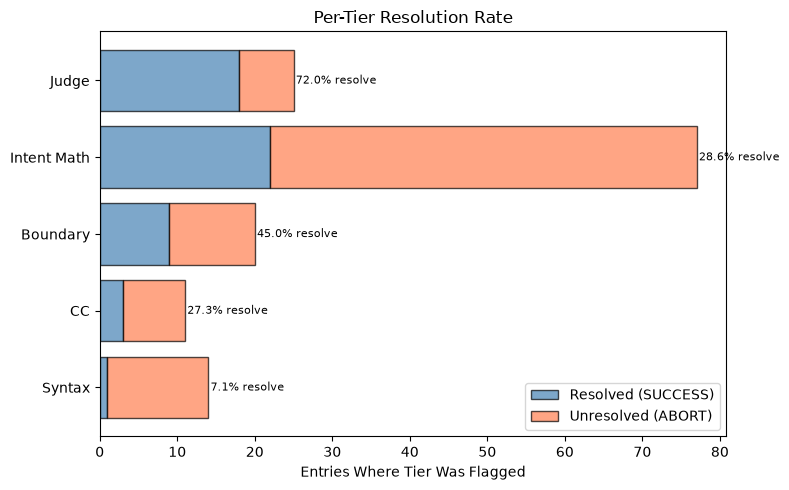

In [5]:
tier_map = {
    'FailureTier.TIER_1_SYNTAX': 'Syntax',
    'FailureTier.TIER_2_A_COMPLEXITY': 'CC',
    'FailureTier.TIER_2_B_BOUNDARY': 'Boundary',
    'FailureTier.TIER_2_C_INTENT_MATH': 'Intent Math',
    'FailureTier.TIER_3_JUDGE': 'Judge',
}
per_tier = {t: {'total': 0, 'success': 0, 'abort': 0} for t in tier_map.values()}

for e in entries:
    findings = e.get('phase4_findings', [])
    seen_tiers = set()
    for f_item in findings:
        tier = f_item.get('tier', '')
        short = tier_map.get(tier, '')
        if short == '':
            continue
        seen_tiers.add(short)
    for t in seen_tiers:
        per_tier[t]['total'] += 1
        if e['exit_status'] == 'SUCCESS':
            per_tier[t]['success'] += 1
        elif e['exit_status'] == 'ABORT_STRATEGY':
            per_tier[t]['abort'] += 1

tiers_order = ['Syntax', 'CC', 'Boundary', 'Intent Math', 'Judge']
print(f"{'Tier':15s} {'Flagged':>8s} {'Resolved':>10s} {'Unresolved':>12s} {'Resolve %':>10s}")
print('-' * 60)
for t in tiers_order:
    d = per_tier[t]
    if d['total'] == 0:
        continue
    resolved_n = d['success']
    unres = d['abort']
    rate = resolved_n / d['total'] * 100
    print(f'{t:15s} {d["total"]:8d} {resolved_n:10d} {unres:12d} {rate:9.1f}%')
print()
print('Caveat: findings are cumulative across iterations.')
print('This is per-entry resolution, not per-iteration pass/fail.')

resolved_list = [per_tier[t]['success'] for t in tiers_order]
unresolved_list = [per_tier[t]['abort'] for t in tiers_order]
pcts = [per_tier[t]['success'] / per_tier[t]['total'] * 100 if per_tier[t]['total'] > 0 else 0 for t in tiers_order]

fig, ax = plt.subplots(figsize=(8, 5))
y_pos = np.arange(len(tiers_order))
bars1 = ax.barh(y_pos, resolved_list, color='steelblue', alpha=0.7, edgecolor='black', label='Resolved (SUCCESS)')
bars2 = ax.barh(y_pos, unresolved_list, left=resolved_list, color='coral', alpha=0.7, edgecolor='black', label='Unresolved (ABORT)')
ax.set_yticks(y_pos)
ax.set_yticklabels(tiers_order, fontsize=10)
ax.set_xlabel('Entries Where Tier Was Flagged')
ax.set_title('Per-Tier Resolution Rate')
ax.legend(loc='lower right')
for i, (res, unres, rate) in enumerate(zip(resolved_list, unresolved_list, pcts)):
    total = res + unres
    if total > 0:
        ax.text(total + 0.3, y_pos[i], f'{rate:.1f}% resolve', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('charts/iter/resolution_by_tier.png', dpi=100)
plt.show()


#### Summary

**Overall**: Only 36.2% of validator-flagged entries eventually succeed. The validator is highly effective at identifying unrecoverable issues (63.8% of flagged runs abort).

**By Difficulty**: Medium difficulty tasks are the bottleneck (76 flagged entries, 31.6% resolution). The strategy agent handles Easy (44.0%) and Hard (42.3%) tasks comparably, suggesting Medium tasks contain edge cases the planner struggles to correct.

**Per-Tier**: Syntax errors are near-fatal (7.1% resolve). Intent math is flagged most frequently (77 entries) with low 28.6% resolvability, making it the dominant bottleneck by volume. Judge flags are the most survivable (72.0%). CC (27.3%) and boundary (45.0%) have moderate resolvability.

**Implication**: To improve the multi-agent system's resolution rate, priority should be: (1) preventing syntax errors through stronger generator guardrails, (2) improving intent-math recovery through better strategy replanning, and (3) considering whether non-syntax tier thresholds should be relaxed given high judge-override success (72%).
